In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_auc_score,
                             roc_curve, classification_report)

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [ ]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (7043, 21)

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
print("\n--- Basic Info ---")
print(df.info())

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Churn Distribution ---")
print(df['Churn'].value_counts())




--- Basic Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043

Text(0, 0.5, 'Count')

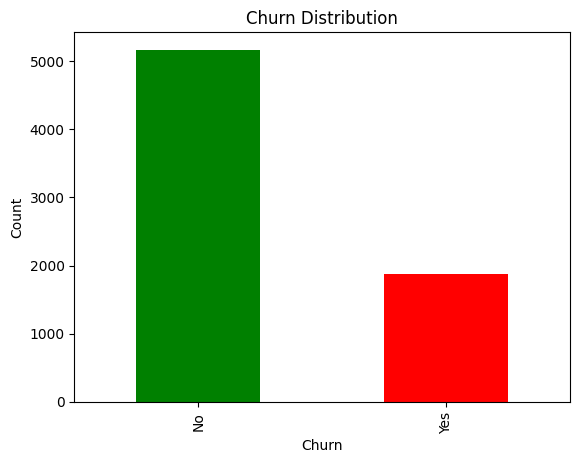

In [ ]:

df['Churn'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')


/tmp/ipykernel_10733/3755893910.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette='Set3')


Text(0.5, 1.0, 'Monthly Charges vs Churn')

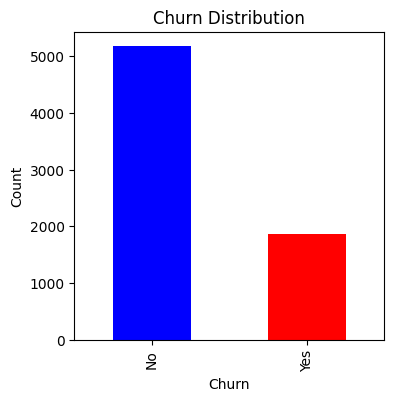

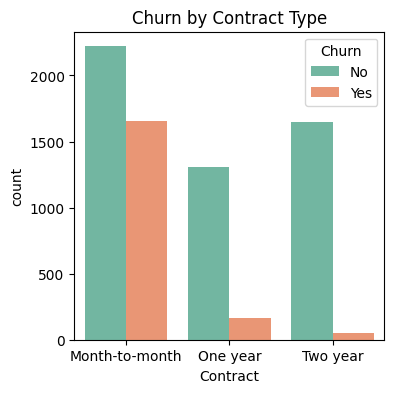

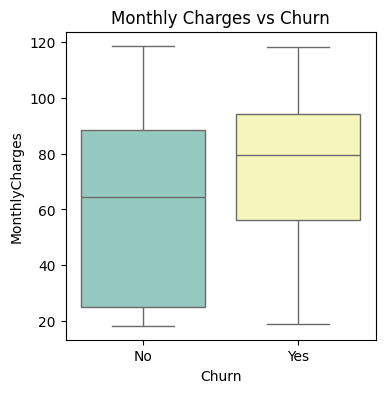

In [ ]:
plt.figure(figsize=(4, 4))
df['Churn'].value_counts().plot(kind='bar', color=['blue', 'red'])
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')

# Plot 2: Churn by Contract Type
plt.figure(figsize=(4, 4))
sns.countplot(data=df, x='Contract', hue='Churn', palette='Set2')
plt.title('Churn by Contract Type')

# Plot 3: Monthly Charges vs Churn
plt.figure(figsize=(4, 4))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette='Set3')
plt.title('Monthly Charges vs Churn')





In [ ]:
# Drop customerID — not useful for prediction
df.drop('customerID', axis=1, inplace=True)

# Fix TotalCharges — it's stored as string, convert to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill the ~11 NaN values in TotalCharges with median
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Encode target column: Yes=1, No=0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Encode all other categorical columns using LabelEncoder
le = LabelEncoder()
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print("\nDataset after encoding:")
print(df.head())
print("\nData types:")
print(df.dtypes)


Dataset after encoding:
   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       0              0        1           0       1             0   
1       1              0        0           0      34             1   
2       1              0        0           0       2             1   
3       1              0        0           0      45             0   
4       0              0        0           0       2             1   

   MultipleLines  InternetService  OnlineSecurity  OnlineBackup  \
0              1                0               0             2   
1              0                0               2             0   
2              0                0               2             2   
3              1                0               2             0   
4              0                1               0             0   

   DeviceProtection  TechSupport  StreamingTV  StreamingMovies  Contract  \
0                 0            0            0                0       

/tmp/ipykernel_10733/1697754819.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [ ]:
# Separate features (X) and target (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

# Train-Test Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")

# Feature Scaling (important for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


Training samples: 5634
Testing samples:  1409


In [ ]:
#training models:
#model1
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr  = lr.predict_proba(X_test_scaled)[:, 1]

#model2
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
y_prob_dt  = dt.predict_proba(X_test)[:, 1]

#model3
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf  = rf.predict_proba(X_test)[:, 1]

In [ ]:
print("\n--- GridSearchCV: Decision Tree ---")
dt_params = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42),
                       dt_params, cv=5, scoring='f1', n_jobs=-1)
dt_grid.fit(X_train, y_train)
print("Best DT Params:", dt_grid.best_params_)

# Best Decision Tree
best_dt = dt_grid.best_estimator_
y_pred_best_dt = best_dt.predict(X_test)
y_prob_best_dt  = best_dt.predict_proba(X_test)[:, 1]


print("\n--- GridSearchCV: Random Forest ---")
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42),
                       rf_params, cv=5, scoring='f1', n_jobs=-1)
rf_grid.fit(X_train, y_train)
print("Best RF Params:", rf_grid.best_params_)

# Best Random Forest
best_rf = rf_grid.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)
y_prob_best_rf  = best_rf.predict_proba(X_test)[:, 1]


--- GridSearchCV: Decision Tree ---
Best DT Params: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 2}

--- GridSearchCV: Random Forest ---
Best RF Params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 50}


In [ ]:
def evaluate_model(name, y_true, y_pred, y_prob):
    """Prints all evaluation metrics for a model."""
    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(f"  Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
    print(f"  Precision : {precision_score(y_true, y_pred):.4f}")
    print(f"  Recall    : {recall_score(y_true, y_pred):.4f}")
    print(f"  F1-Score  : {f1_score(y_true, y_pred):.4f}")
    print(f"  ROC-AUC   : {roc_auc_score(y_true, y_prob):.4f}")
    print(f"\nClassification Report:\n{classification_report(y_true, y_pred)}")
    return {
        'Model': name,
        'Accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred), 4),
        'Recall':    round(recall_score(y_true, y_pred), 4),
        'F1-Score':  round(f1_score(y_true, y_pred), 4),
        'ROC-AUC':   round(roc_auc_score(y_true, y_prob), 4),
    }

# Evaluate all models
results = []
results.append(evaluate_model("Logistic Regression",      y_test, y_pred_lr,      y_prob_lr))
results.append(evaluate_model("Decision Tree (Tuned)",    y_test, y_pred_best_dt,  y_prob_best_dt))
results.append(evaluate_model("Random Forest (Tuned)",    y_test, y_pred_best_rf,  y_prob_best_rf))

# Summary Table
results_df = pd.DataFrame(results)
print("\n\n--- MODEL COMPARISON TABLE ---")
print(results_df.to_string(index=False))


  Logistic Regression
  Accuracy  : 0.7991
  Precision : 0.6426
  Recall    : 0.5481
  F1-Score  : 0.5916
  ROC-AUC   : 0.8403

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1035
           1       0.64      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409


  Decision Tree (Tuned)
  Accuracy  : 0.7842
  Precision : 0.6017
  Recall    : 0.5535
  F1-Score  : 0.5766
  ROC-AUC   : 0.8217

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.87      0.86      1035
           1       0.60      0.55      0.58       374

    accuracy                           0.78      1409
   macro avg       0.72      0.71      0.72      1409
weighted avg       0.78      0.78      0.78      1409


  Random Forest (Tuned)
  Accuracy  : 0

In [ ]:
# Confusion Matrices

models_info = [
    ("Logistic Regression", y_pred_lr),
    ("Decision Tree (Tuned)", y_pred_best_dt),
    ("Random Forest (Tuned)", y_pred_best_rf),
]

for name, y_pred in models_info:
    print(f"\n{'='*45}")
    print(f"{name} - Confusion Matrix")
    print(f"{'='*45}")

    cm = confusion_matrix(y_test, y_pred)

    print(cm)


Logistic Regression - Confusion Matrix
[[921 114]
 [169 205]]

Decision Tree (Tuned) - Confusion Matrix
[[898 137]
 [167 207]]

Random Forest (Tuned) - Confusion Matrix
[[931 104]
 [177 197]]


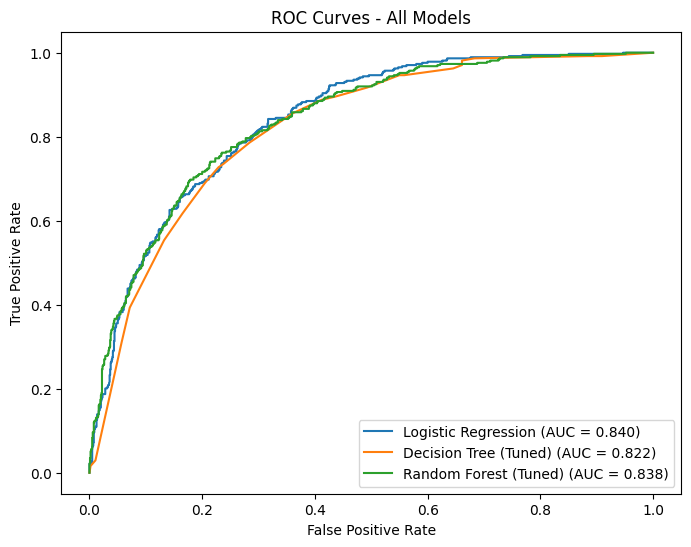

In [ ]:
# ROC CURVES
plt.figure(figsize=(8, 6))

for name, y_prob in [("Logistic Regression",   y_prob_lr),
                      ("Decision Tree (Tuned)", y_prob_best_dt),
                      ("Random Forest (Tuned)", y_prob_best_rf)]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")


plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - All Models')
plt.legend()


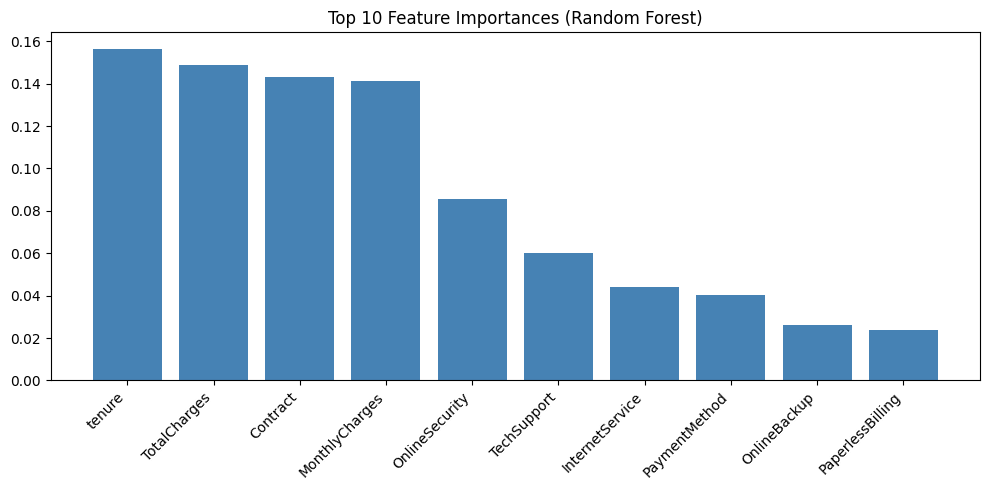

In [ ]:

feature_names = X.columns
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1][:10]  # Top 10 features

plt.figure(figsize=(10, 5))
plt.bar(range(10), importances[indices], color='steelblue')
plt.xticks(range(10), feature_names[indices], rotation=45, ha='right')
plt.title('Top 10 Feature Importances (Random Forest)')
plt.tight_layout()
plt.show()

In [ ]:
print("\n\n========== FINAL RESULTS ==========")
best_model_row = results_df.loc[results_df['F1-Score'].idxmax()]
print(f"Best Model by F1-Score: {best_model_row['Model']}")
print(f"  Accuracy  : {best_model_row['Accuracy']}")
print(f"  F1-Score  : {best_model_row['F1-Score']}")
print(f"  ROC-AUC   : {best_model_row['ROC-AUC']}")
print("====================================")



========== FINAL RESULTS ==========
Best Model by F1-Score: Logistic Regression
  Accuracy  : 0.7991
  F1-Score  : 0.5916
  ROC-AUC   : 0.8403
